### Versão do Python

In [2]:
import sys
print(sys.version)

3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


### Exportando requirements.txt

In [3]:
!pip freeze > requirements.txt

### Instalação da biblioteca Kaggle

In [4]:
!pip install kaggle

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


### Lendo chave da API do Kaggle

In [5]:
import os
import json

# Obtém o diretório atual do notebook
current_dir = os.getcwd()

# Junta o diretório atual com o nome do arquivo kaggle.json
# Garantir que o arquivo kaggle.json esteja no mesmo diretório do notebook

kaggle_json_path = os.path.join(current_dir, "kaggle.json")

print(f"Caminho do kaggle.json (relativo ao notebook): {kaggle_json_path}")

#Leia as credenciais do arquivo (o restante do seu código)
try:
    with open(kaggle_json_path, 'r') as f:
        data = json.load(f)
        
    os.environ['KAGGLE_USERNAME'] = data['username']
    os.environ['KAGGLE_KEY'] = data['key']
    
    print("Credenciais do Kaggle configuradas com sucesso!")
    
except FileNotFoundError:
    print(f"Erro: O arquivo kaggle.json não foi encontrado em {kaggle_json_path}")



Caminho do kaggle.json (relativo ao notebook): c:\Projetos\especializacao_ia\setimo_modulo_validacao_modelos_clusterizacao\kaggle.json
Credenciais do Kaggle configuradas com sucesso!


### Bibliotecas utilizadas no projeto

In [6]:
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import math
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.cluster import DBSCAN

### Baixando Dataset unsupervised-learning-on-country-data diretamente da api do Kaggle

In [7]:

#Cria uma instância da API
api = KaggleApi()

#Autentiqua usando as variáveis de ambiente (configuradas na Célula 2)
api.authenticate()

#Defina o identificador do dataset
dataset_id = 'rohan0301/unsupervised-learning-on-country-data'
download_path = '.'

print(f"Baixando o dataset {dataset_id}...")

#Execute o download
# unzip=True fará com que o arquivo .zip seja automaticamente descompactado
api.dataset_download_files(dataset_id, path=download_path, unzip=True)

print("\nDownload e descompactação concluídos!")

Baixando o dataset rohan0301/unsupervised-learning-on-country-data...
Dataset URL: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

Download e descompactação concluídos!


In [8]:
df = pd.read_csv('Country-data.csv')
df.head()

df.info()   


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [9]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Análise do Dataset

 


### **Descrição das Variáveis**

* **country:** Nome do país.
* **child_mort:** Mortes de crianças menores de 5 anos por 1.000 nascidos vivos.
* **exports:** Exportações de bens e serviços (% do PIB per capita).
* **health:** Gastos totais em saúde (% do PIB per capita).
* **imports:** Importações de bens e serviços (% do PIB per capita).
* **income:** Renda líquida per capita (USD).
* **inflation:** Taxa anual de crescimento do PIB (%).
* **life_expec:** Expectativa de vida ao nascer (anos).
* **total_fer:** Número médio de filhos por mulher.
* **gdpp:** PIB per capita (USD).

 



#### **Quantidade de Países Únicos**

In [10]:
df['country'].nunique()

167

## **Faixa Dinâmica de Valores em Cada Coluna Numérica do Dataset**

Antes da etapa de **clusterização**, é fundamental realizar uma **análise e pré-processamento dos dados**.
Essa etapa garante que as variáveis estejam em um **formato e escala adequados** para os algoritmos de agrupamento.

Na análise realizada, observamos:

* Muitos **outliers** em diversas features.
* Falta de **padronização de escala** entre as variáveis.

Por isso, optou-se por **exibir o boxplot individual por feature** nesta fase.
Após o pré-processamento, será possível **visualizar todas as features em uma mesma escala**.

---

## **Etapas Fundamentais antes da Clusterização**

### 1. **Limpeza dos Dados**

* Remover ou imputar valores ausentes.
* Eliminar duplicatas.
* Corrigir inconsistências, como **erros de digitação ou formatação**.

---

### 2. **Seleção e Transformação de Variáveis**

* Escolher as **features mais relevantes** para o problema.
* Converter variáveis categóricas em numéricas (ex.: **One-Hot Encoding**).
* Se necessário, aplicar técnicas de **redução de dimensionalidade**, como **PCA**.

---

### 3. **Normalização ou Padronização**

* Escalar os dados para que todas as variáveis tenham **influência equivalente na distância**.
* Exemplos de técnicas:

  * **StandardScaler**
  * **RobustScaler**
  * **MinMaxScaler**

---

### 4. **Tratamento de Outliers**

* Esta etapa é necessária, mas pode ser **problemática**.
* Manter outliers pode prejudicar o desenvolvimento do modelo, mas **removê-los sem critério também pode ser um erro**.
* A decisão depende do **objetivo final do negócio**.

---

### 5. **Verificação da Distribuição dos Dados**

* Analisar a distribuição das features é fundamental antes de aplicar qualquer modelo de machine learning.
* Alguns tipos de dados são mais adequados para certos modelos:

  * Exemplo: datasets semelhantes ao **make_moons** do Sklearn não são ideais para **K-Means**.
* Essa análise permite **entender melhor o problema** e **selecionar o modelo mais eficiente**.



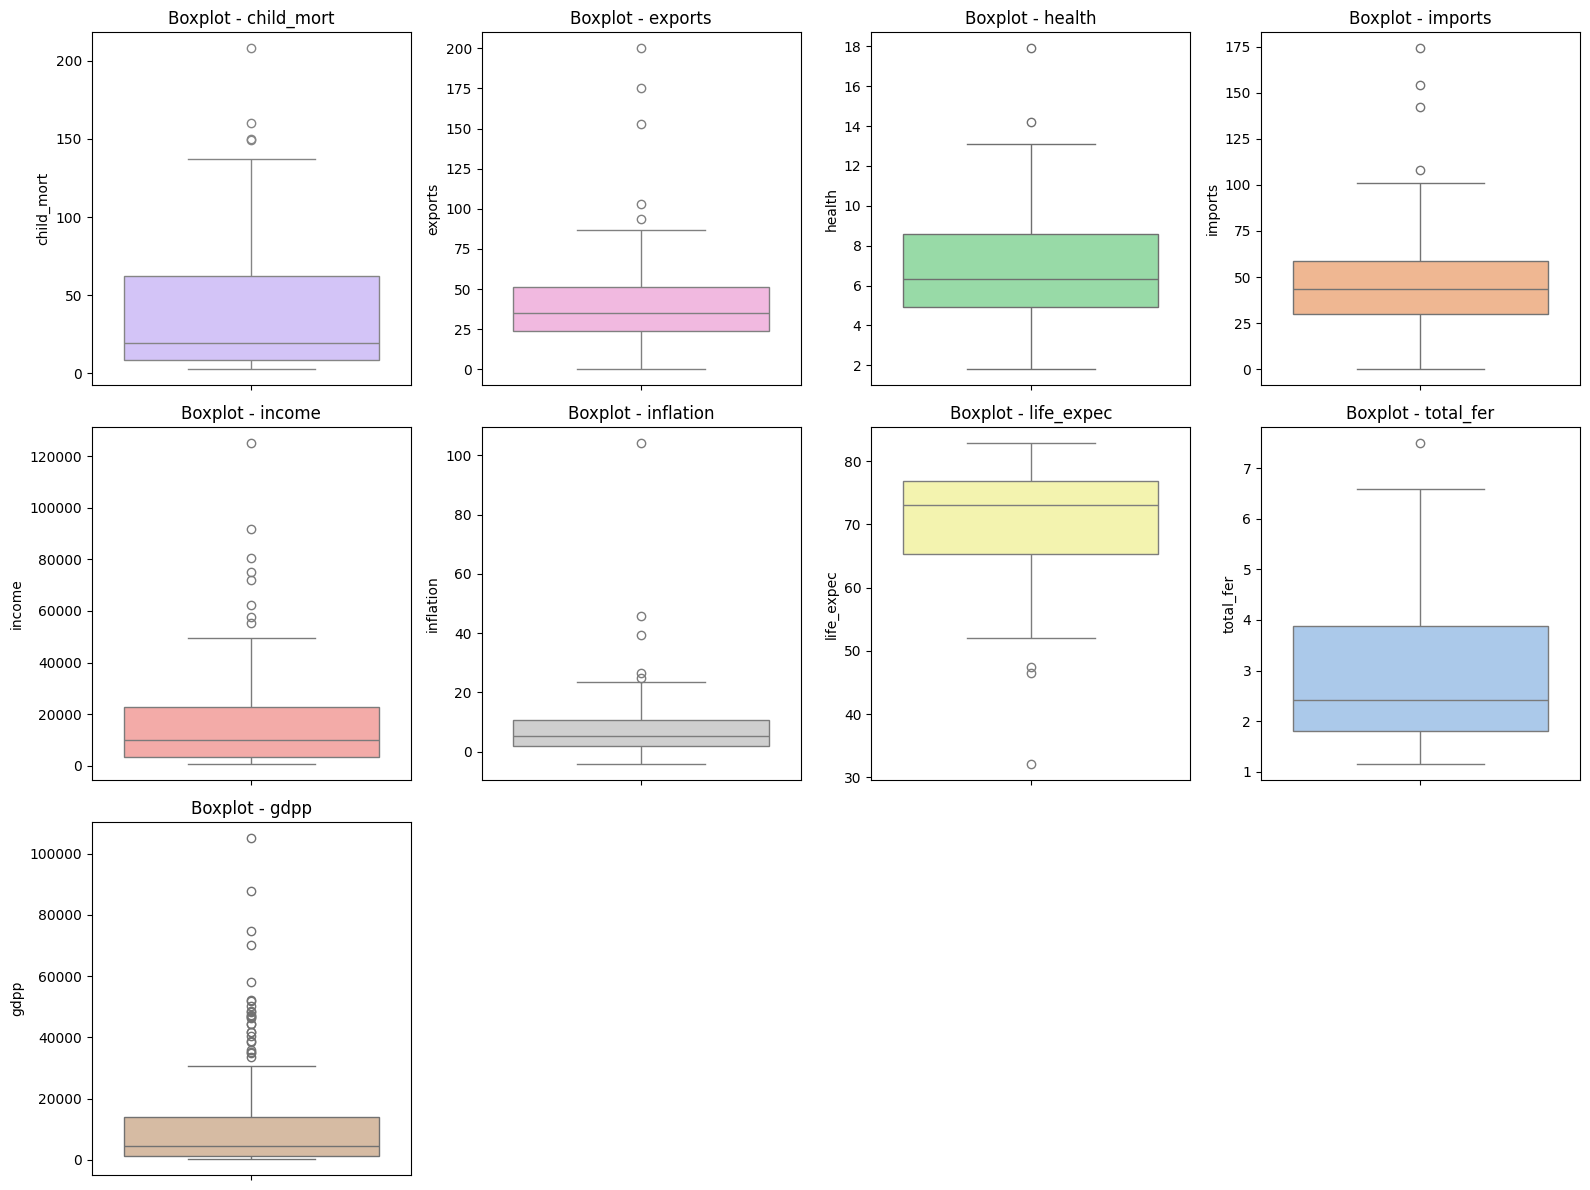

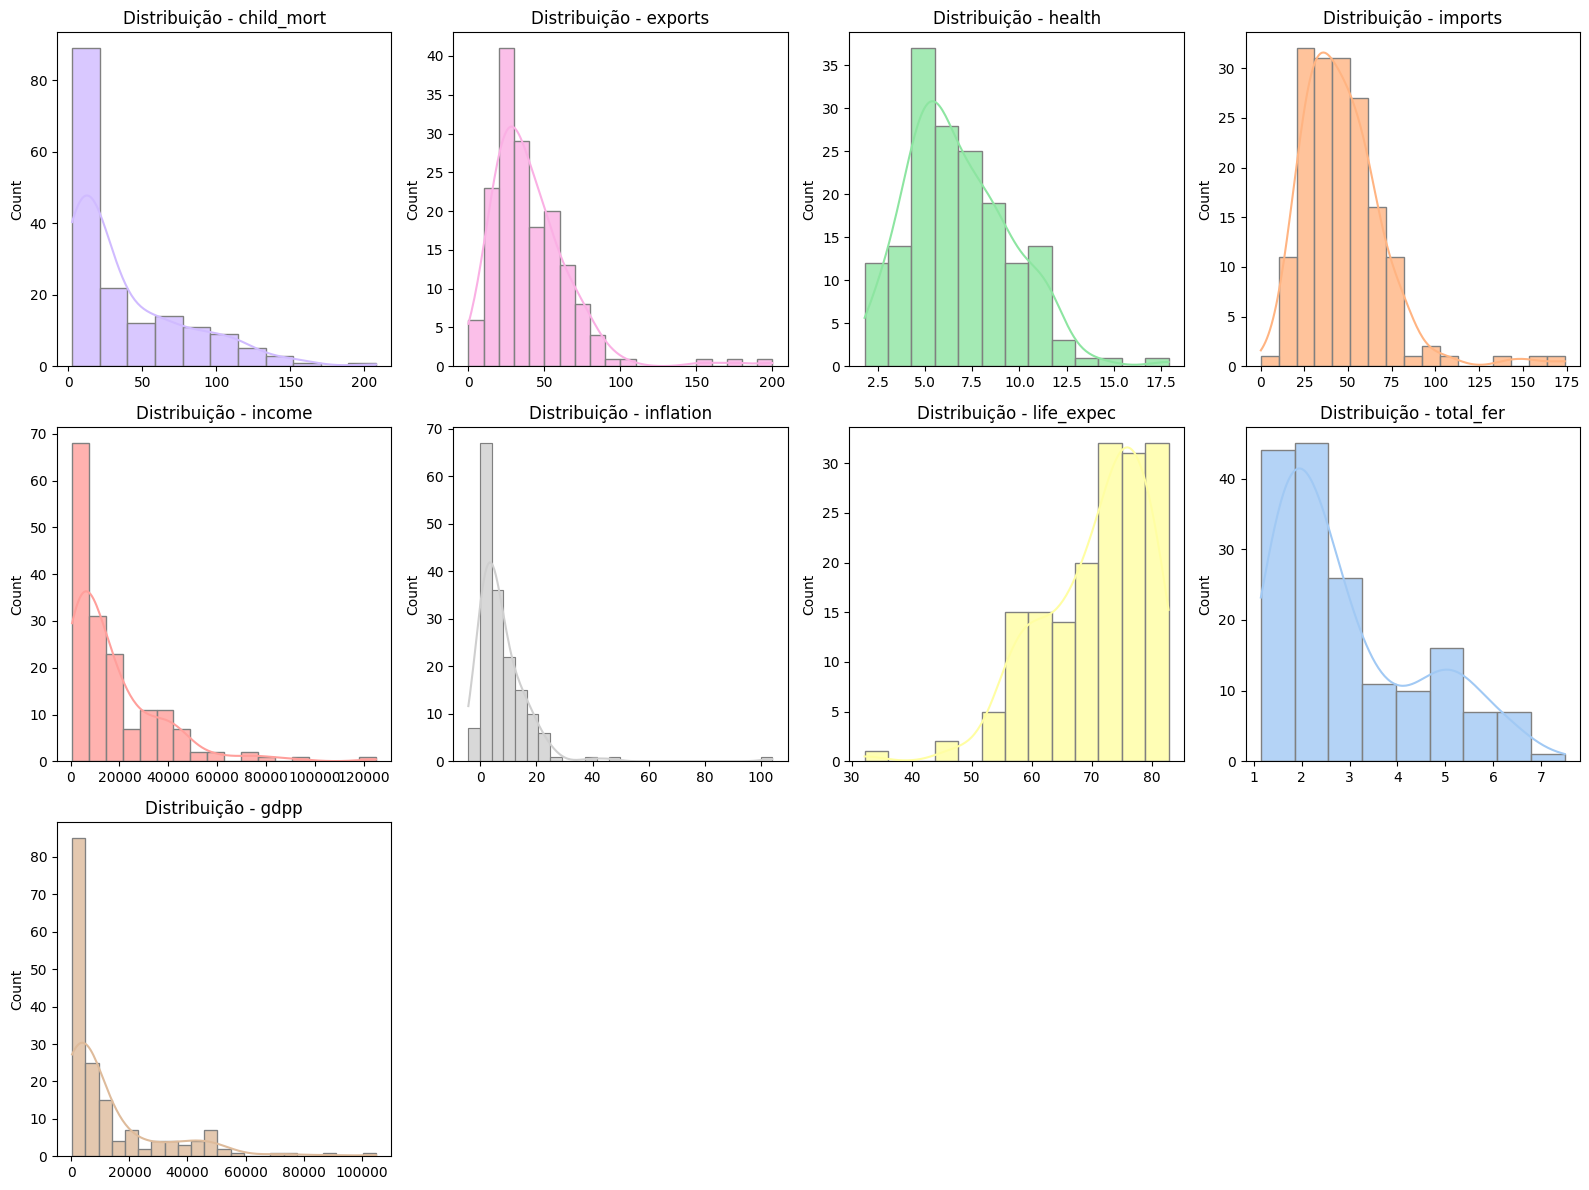

C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Bruno Adalberto\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigne

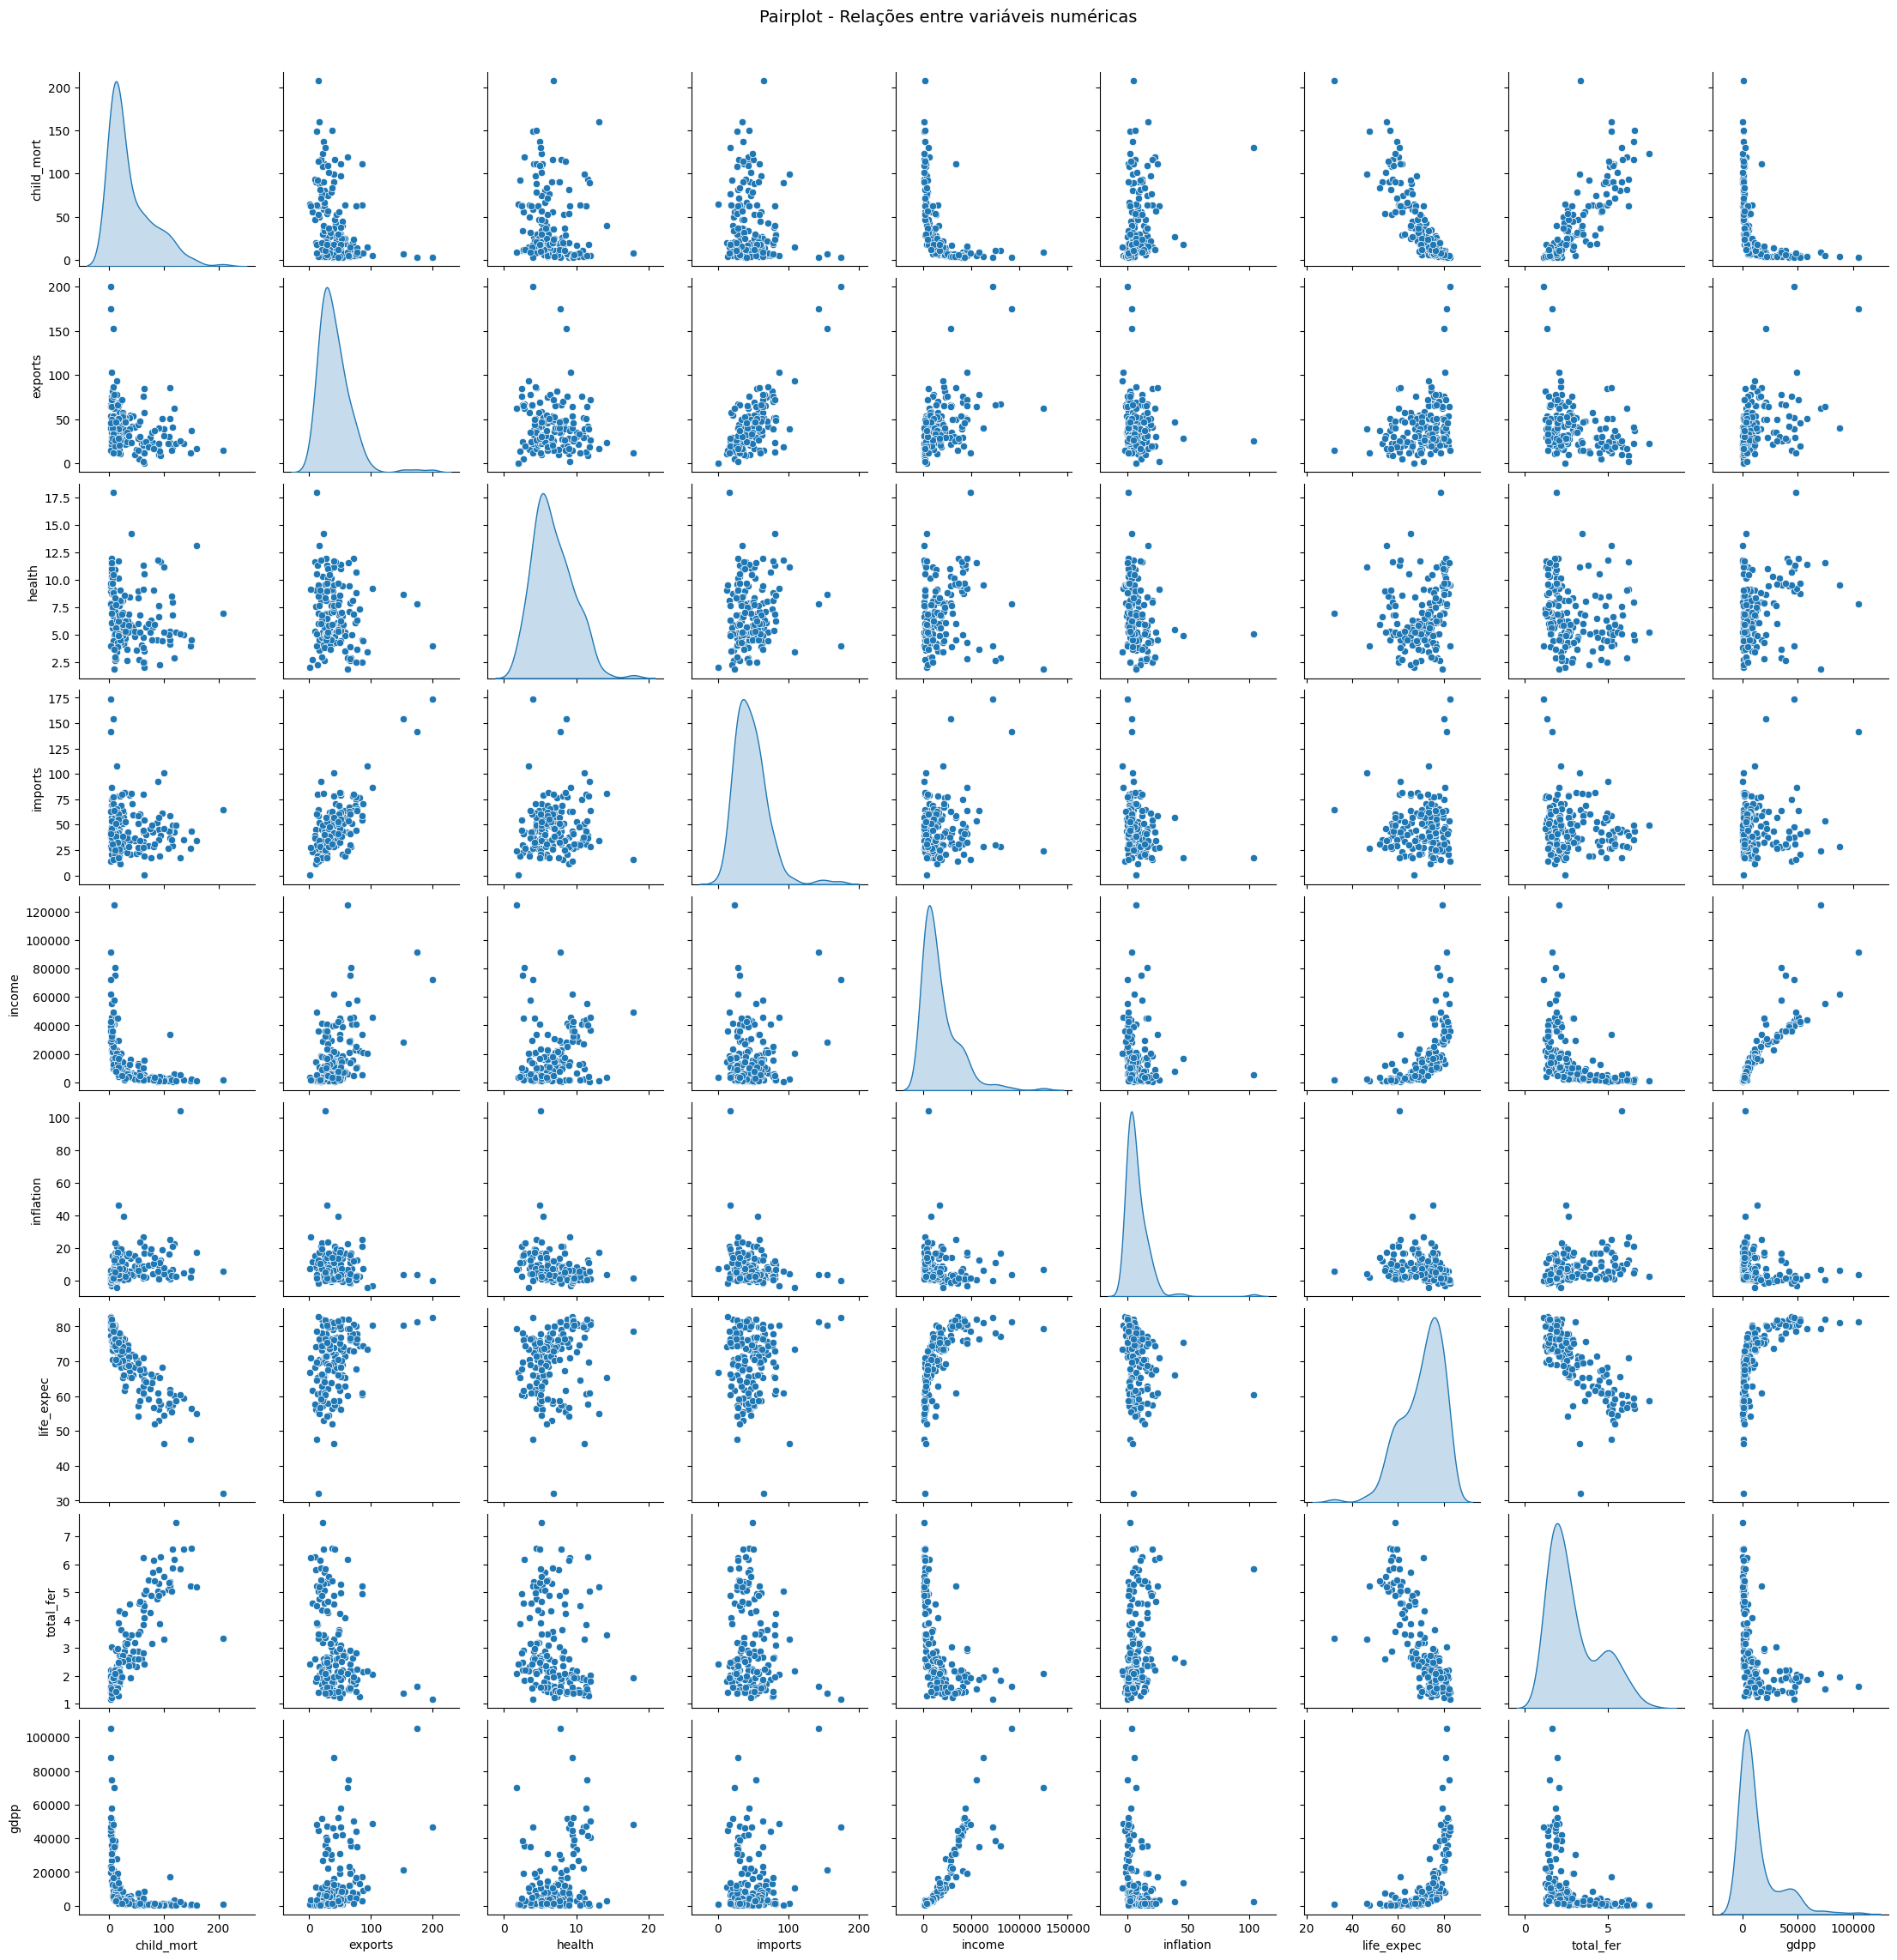

In [11]:
# Seleciona colunas numéricas
cols = df.select_dtypes(include=['float64', 'int64']).columns
n = len(cols)

# Grid de subplots
n_cols = 4
n_rows = math.ceil(n / n_cols)

# Paleta de cores suaves (pastel tones)
palette = sns.color_palette("pastel", n)
random.shuffle(palette)  # embaralha para variar as cores entre execuções

# Boxplots verticais
# ========================
plt.figure(figsize=(16, 4*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    color = palette[i-1]
    sns.boxplot(y=df[col], color=color)  # vertical (em pé)
    plt.title(f'Boxplot - {col}')
    plt.xlabel('')
    plt.tight_layout()

plt.show()

# Histogramas com KDE
# ========================
plt.figure(figsize=(16, 4*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    color = palette[i-1]
    sns.histplot(df[col], kde=True, color=color, edgecolor='gray', alpha=0.8)
    plt.title(f'Distribuição - {col}')
    plt.xlabel('')
    plt.tight_layout()

plt.show()

num_df = df.select_dtypes(include=['float64', 'int64'])
# Pairplot completo
sns.pairplot(num_df, diag_kind="kde", palette="tab10")

plt.suptitle("Pairplot - Relações entre variáveis numéricas", y=1.02, fontsize=14)
plt.show()


Valores ausentes por coluna:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Registros duplicados: 0

Shape após remoção de 'country': (167, 9)

Estatísticas após padronização:
            count          mean       std       min       25%       50%  \
child_mort  167.0 -3.722904e-17  1.003008 -0.887138 -0.746619 -0.471798   
exports     167.0  2.127373e-16  1.003008 -1.500192 -0.633337 -0.223528   
health      167.0  5.504579e-16  1.003008 -1.827827 -0.692211 -0.181001   
imports     167.0  2.765585e-16  1.003008 -1.939940 -0.691479 -0.148743   
income      167.0 -7.977650e-17  1.003008 -0.860326 -0.717456 -0.373808   
inflation   167.0 -1.063687e-17  1.003008 -1.137852 -0.566641 -0.226950   
life_expec  167.0  3.696311e-16  1.003008 -4.337186 -0.592758  0.286958   
total_fer   167.0  3.044803e-16  1.003008 -1.191250 -0.763902 -0.356431   
gdpp        167.0  5.

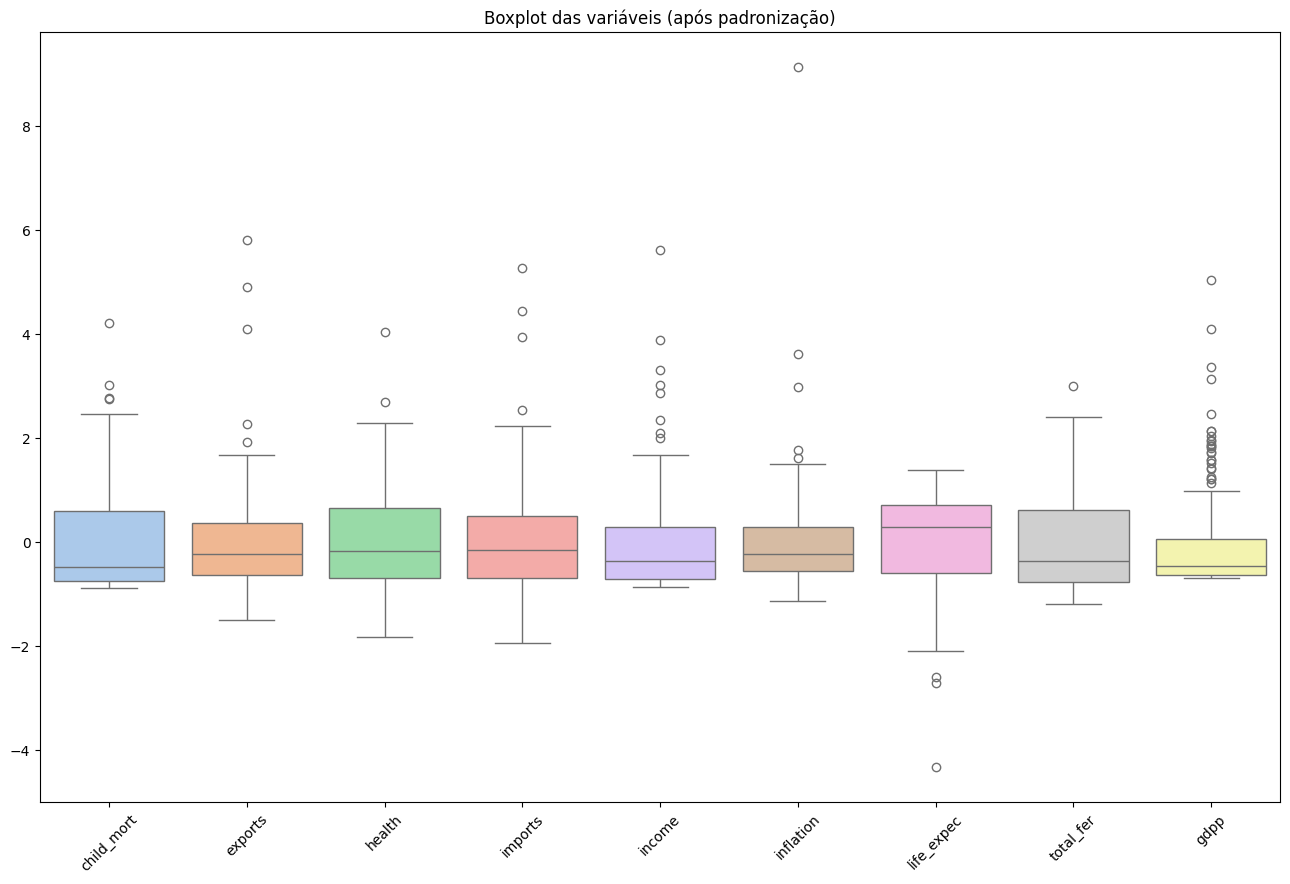

In [12]:
# Verifica se há valores ausentes ou duplicados
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nRegistros duplicados:", df.duplicated().sum())


df_num = df.drop(columns=['country'])
print("\nShape após remoção de 'country':", df_num.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# Converte para DataFrame novamente
df_scaled = pd.DataFrame(X_scaled, columns=df_num.columns)

print("\nEstatísticas após padronização:")
print(df_scaled.describe().T)


# =======================================================
# Visualização após o scaling
# =======================================================
plt.figure(figsize=(16, 10))
sns.boxplot(data=df_scaled, palette="pastel")
plt.xticks(rotation=45)
plt.title("Boxplot das variáveis (após padronização)")
plt.show()

### Avaliação de K utilizando técnica ELBOW

In [55]:
#variando k de 1 até 10

k_values = range(1, 11)
wss_list = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wss = kmeans.inertia_
    wss_list.append(wss)

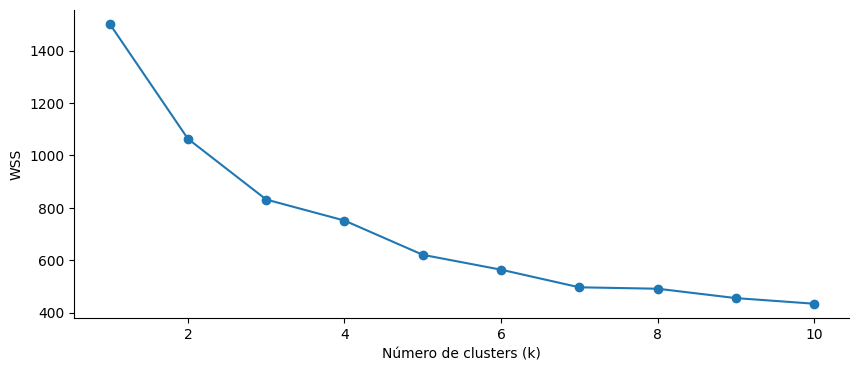

In [56]:
def plot_elbow(wss_list, init_k=1):
    f, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(init_k,(len(wss_list) + 1)), wss_list, marker='o')
    ax.set_xlabel('Número de clusters (k)')
    ax.set_ylabel('WSS')

    sns.despine()
    plt.show()

plot_elbow(wss_list)

Text(0.5, 0, 'child_mort')

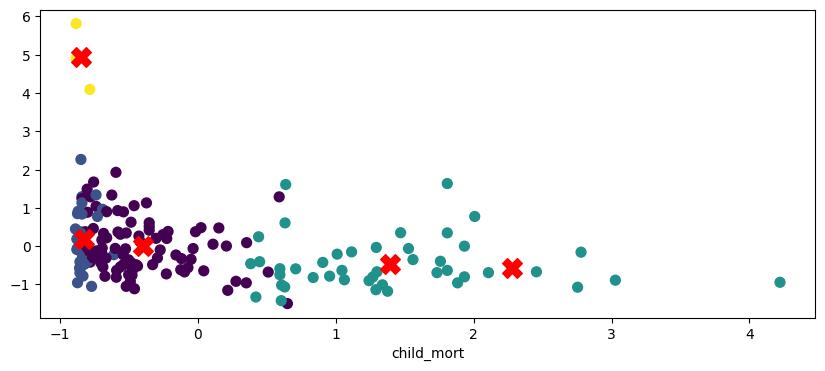

In [57]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(df_scaled)

f,ax = plt.subplots(figsize=(10,4))
ax.scatter(df_scaled.iloc[:, 0], df_scaled.iloc[:, 1], c=kmeans.labels_, cmap='viridis', s=50)
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='X', label='Centroids')
ax.set_xlabel(df_scaled.columns[0]) 

In [58]:
wss_list = [
    KMeans(n_clusters=k, random_state=42).fit(df_scaled).inertia_ for k in range(1, 11)
]

In [59]:
from sklearn.metrics import silhouette_score

cluster_per_k = [KMeans(n_clusters=k, random_state=42).fit(df_scaled) for k in range(2, 11)]

silhouette_score_list = [
    silhouette_score(df_scaled, cluster.labels_) for cluster in cluster_per_k
]


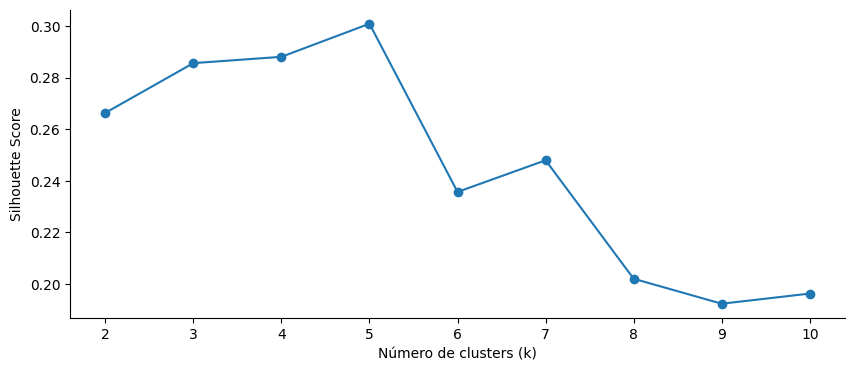

In [ ]:

f, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(2, 11), silhouette_score_list, marker='o')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette Score')
sns.despine()
plt.show()


- **Método do Cotovelo:** indica estabilização a partir de **k = 5**.  
- **Silhouette Score:** atinge seu valor máximo em **k = 5**.

Os dois critérios apontam para a mesma escolha. Portanto, **k = 5** foi adotado como o número ótimo de clusters para o agrupamento via K-Means.


In [65]:
# Aplica o DBSCAN com os parâmetros ajustados
dbscan = DBSCAN(eps=1.2, min_samples=4, metric='euclidean')
dbscan.fit(df_scaled)

# Cria coluna de cluster
df['Cluster_DBSCAN'] = dbscan.labels_

# Conta e ordena os clusters do menor para o maior
cluster_counts = df['Cluster_DBSCAN'].value_counts().sort_values(ascending=True)

print("\n Distribuição dos clusters (ordenado do menor para o maior):")
print(cluster_counts)

# Mostra número total de clusters válidos
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
print(f"\nNúmero de clusters detectados (sem contar ruído): {n_clusters}")

# Mostra quantos países foram considerados ruído
outliers = list(df['Cluster_DBSCAN']).count(-1)
print(f"Outliers (ruído): {outliers}")


 Distribuição dos clusters (ordenado do menor para o maior):
Cluster_DBSCAN
 2    18
 0    23
-1    50
 1    76
Name: count, dtype: int64

Número de clusters detectados (sem contar ruído): 3
Outliers (ruído): 50


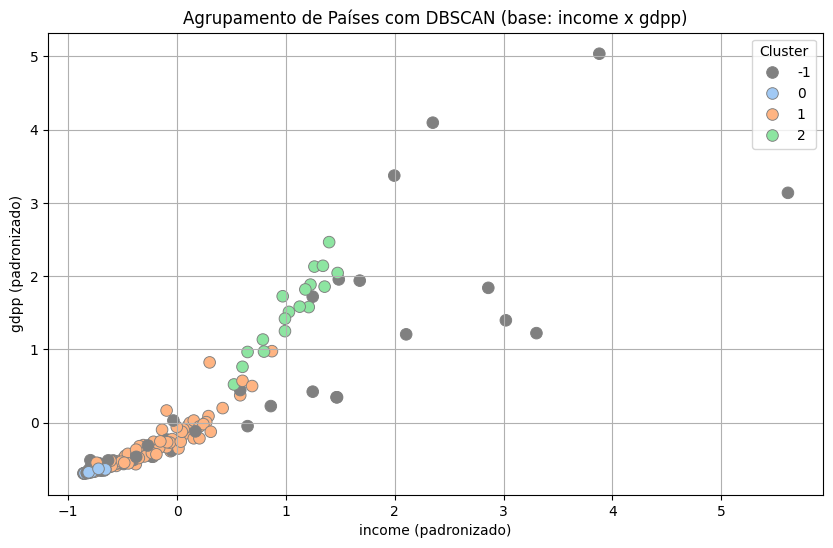

In [66]:
 
#Escolhe as duas variáveis principais
x_var = 'income'
y_var = 'gdpp'

#Cria um DataFrame com os dados padronizados e os rótulos do DBSCAN
X_plot = df_scaled[[x_var, y_var]].copy()
X_plot['Cluster_DBSCAN'] = df['Cluster_DBSCAN']

#Define as cores — outliers (-1) em cinza
palette = sns.color_palette("pastel", len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0))
palette = ['gray'] + palette  # adiciona o cinza para os outliers primeiro

#Cria o gráfico
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=X_plot,
    x=x_var, 
    y=y_var,
    hue='Cluster_DBSCAN',
    palette=palette,
    s=70,
    edgecolor='gray'
)

#Personaliza o gráfico
plt.title("Agrupamento de Países com DBSCAN (base: income x gdpp)")
plt.xlabel(f"{x_var} (padronizado)")
plt.ylabel(f"{y_var} (padronizado)")
plt.legend(title="Cluster", loc='best')
plt.grid(True)
plt.show()


Silhouette do DBSCAN: 0.149


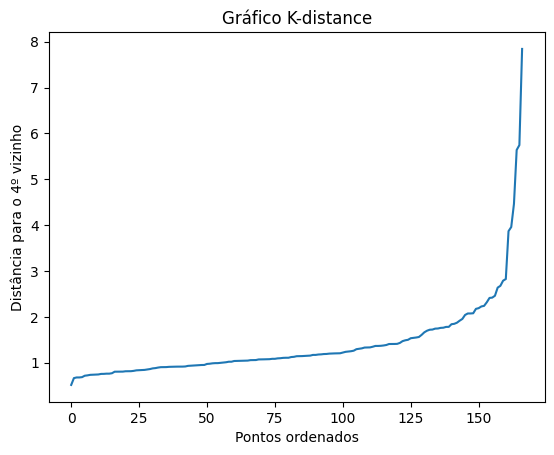

In [67]:
from sklearn.neighbors import NearestNeighbors

if n_clusters > 1:
    sil = silhouette_score(df_scaled, dbscan.labels_)
    print(f"Silhouette do DBSCAN: {sil:.3f}")
else:
    print("DBSCAN gerou apenas 1 cluster, Silhouette não aplicável.")


neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances[:, 3])  # 3 porque min_samples=4
plt.plot(distances)
plt.title("Gráfico K-distance")
plt.xlabel("Pontos ordenados")
plt.ylabel("Distância para o 4º vizinho")
plt.show()


In [73]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

k_range = range(2, 11)  # Avaliando de 2 até 10 clusters

ch_scores = []
db_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42).fit(df_scaled)
    ch_scores.append(calinski_harabasz_score(df_scaled, model.labels_))
    db_scores.append(davies_bouldin_score(df_scaled, model.labels_))


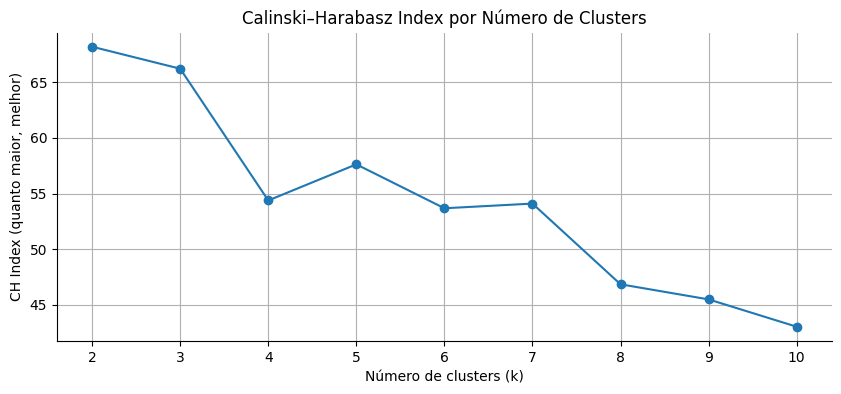

In [74]:
plt.figure(figsize=(10, 4))
plt.plot(k_range, ch_scores, marker='o')
plt.title("Calinski–Harabasz Index por Número de Clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("CH Index (quanto maior, melhor)")
plt.grid(True)
sns.despine()
plt.show()


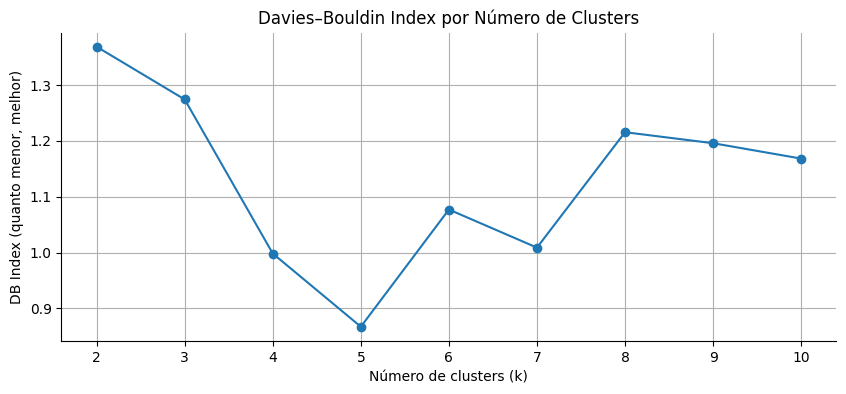

In [75]:
plt.figure(figsize=(10, 4))
plt.plot(k_range, db_scores, marker='o')
plt.title("Davies–Bouldin Index por Número de Clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("DB Index (quanto menor, melhor)")
plt.grid(True)
sns.despine()
plt.show()


# Análise de Agrupamento: K-Means, DBSCAN e Métricas de Validação

---

## 1. Cálculo do Índice de Silhueta

A silhueta mede o quão bem cada ponto foi associado ao seu cluster. Para cada observação \(i\):

1. **Coesão interna \(a(i)\)**  
   Média das distâncias entre \(i\) e os demais pontos do **mesmo cluster** \(C_{i}\):
   $$
   a(i) \;=\; \frac{1}{|C_{i}|-1}\sum_{\substack{j\in C_{i}\\ j\neq i}} d(i,j)
   $$

2. **Separação entre clusters \(b(i)\)**  
   Para cada cluster diferente \(C\), calcula-se a média das distâncias entre \(i\) e os pontos de \(C\); \(b(i)\) é o menor desses valores:
   $$
   b(i) \;=\; \min_{C \neq C_{i}} \frac{1}{|C|}\sum_{j\in C} d(i,j)
   $$

3. **Silhueta individual**  
   $$
   s(i) \;=\; \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}
   $$

4. **Silhueta geral**  
   Média aritmética de \(s(i)\) para todas as observações:
   $$
   S \;=\; \frac{1}{n}\sum_{i=1}^{n} s(i)
   $$

**Interpretação**
- \(s(i)\) próximo de \(1\) → ponto bem agrupado.  
- \(s(i)\) próximo de \(0\) → ponto na fronteira entre clusters.  
- \(s(i)\) negativo → ponto possivelmente alocado no cluster errado.

---

## 2. Resultados Obtidos com K-Means

### 2.1 Método do Cotovelo
- WSS cai rapidamente até **k = 5**; depois as melhorias são marginais.  
- O “cotovelo” do gráfico sugere **k = 5**.

### 2.2 Silhouette Score para K-Means
- Avaliado para \(k = 2\) até \(10\).  
- Silhueta média máxima em **k = 5**.

**Conclusão:** para K-Means, a escolha mais coerente é **k = 5**.

---

## 3. Resultados Obtidos com DBSCAN

### 3.1 Parâmetros
- `eps = 1.2`  
- `min_samples = 4`

### 3.2 Observações
- Número de clusters encontrados: **n_clusters** (excluindo ruído).  
- Pontos com rótulo **-1** considerados ruído/outliers.  
- Gráfico K-distance usado para suportar a escolha de `eps`.

### 3.3 Silhueta no DBSCAN
- Silhueta só pode ser calculada se houver **mais de um cluster**.  
- Mesmo quando calculável, interpretação é limitada por ruído, formatos não esféricos e variação de densidade.

---

## 4. Comparação: K-Means vs DBSCAN

### Semelhanças
- Ambos usam medidas de distância e visam segmentar os dados.

### Diferenças

| Aspecto | K-Means | DBSCAN |
|--------|---------|--------|
| Número de clusters | Definido antes | Determinado automaticamente |
| Formato dos clusters | Tendem a ser esféricos | Formatos arbitrários |
| Outliers | Não identifica | Identifica (rótulo -1) |
| Sensibilidade | Escala e centróides | Densidade e `eps` |
| Métricas apropriadas | WSS, Silhouette, CH, DB | K-distance, validação por densidade |

**Interpretação:** K-Means estruturou 5 grupos coerentes; DBSCAN destacou regiões densas e ruído. Métodos complementares.

---

## 5. Outras Medidas de Validação: CH e Davies–Bouldin

### 5.1 Calinski–Harabasz (CH)
- Quanto maior, melhor separação.
- Máximo observado em **k = 5**.

### 5.2 Davies–Bouldin (DB)
- Quanto menor, melhor.
- Mínimo também em **k = 5**.

**Conclusão:** Silhouette, CH e Davies–Bouldin convergiram para **k = 5**, reforçando a escolha.

---

## 6. A Silhueta é Indicada para Escolher o Número de Clusters no DBSCAN?

**Não é a melhor escolha.**

**Motivos principais**
1. Ruído (rótulo -1) altera médias de distância.  
2. Clusters com formas arbitrárias não se encaixam bem na suposição da silhueta.  
3. Diferenças de densidade prejudicam a interpretação.  
4. Se DBSCAN retorna um único cluster, a silhueta é inoperante.

**Alternativas mais adequadas**
- Gráfico K-distance;  
- Inspeção visual dos clusters;  
- Ajuste e sensibilidade de `eps` e `min_samples`;  
- Métricas específicas para clusters por densidade (ex.: S_Dbw).

---

## 7. Conclusões Finais

- Para K-Means, as métricas convergiram para **k = 5**.  
- DBSCAN trouxe visão complementar ao identificar densidades e outliers.  
- A silhueta é útil para métodos de particionamento (como K-Means), mas limitada para validação de DBSCAN.  
- Recomenda-se combinar abordagens (métricas + inspeção visual + validação por densidade) para decisões mais sólidas.

---


# Agrupamento de Séries Temporais com Correlação Cruzada

*(resposta em linguagem técnica, mas não excessivamente formal)*

## 1. Passos necessários para agrupar as 10 séries temporais em 3 grupos usando a **correlação cruzada**

1. **Organizar os dados**

   * Garantir que as 10 séries tenham mesmo intervalo e frequência.
   * Tratar valores ausentes caso existam.

2. **Normalizar ou padronizar as séries**

   * Normalização evita que séries com amplitudes diferentes dominem o cálculo de similaridade.
   * Pode ser z-score ou min–max.

3. **Calcular a correlação cruzada entre todas as séries**

   * Para cada par de séries ((X, Y)), calcular a *cross-correlation function (CCF)* ao longo dos atrasos (lags).
   * Extrair o **valor máximo da correlação cruzada** e o respectivo lag.

4. **Construir a matriz de similaridade**

   * Criar uma matriz (10 \times 10), onde cada célula contém o **máximo de correlação cruzada** entre os pares.

5. **Converter similaridade em distância**

   * A maior parte dos algoritmos de clustering trabalha com distância.
   * Exemplo de conversão:
     [
     d(i,j) = 1 - |\rho(i,j)|
     ]

6. **Aplicar um algoritmo de clusterização para gerar 3 grupos**

   * Ajustar para **k = 3** (ou conforme o método escolhido).
   * Usar a matriz de distâncias como entrada.

7. **Validar os agrupamentos**

   * Avaliar coesão e separação usando métricas adequadas.
   * Interpretar se os clusters fazem sentido do ponto de vista temporal.

8. **Interpretar e descrever os grupos**

   * Analisar padrões semelhantes entre séries dentro de cada cluster.

---

## 2. Qual algoritmo de clusterização usar?

### **Resposta curta:** **Hierarchical Clustering (Agglomerative)**

### **Justificativa**

* Funciona bem com **matrizes de distância personalizadas**, como as derivadas de correlação.
* Não exige que os clusters sejam esféricos como no K-Means.
* Permite visualizar a estrutura dos agrupamentos por meio do *dendrograma*.
* O usuário pode definir diretamente o número de clusters (3).
* É amplamente usado para séries temporais quando a similaridade não é baseada em distâncias euclidianas tradicionais.

Outros possíveis (menos adequados neste caso):

* **K-Means:** não é ideal, pois supõe formato esférico e distância euclidiana.
* **DBSCAN:** pode funcionar, mas depende muito da densidade e dos parâmetros.

---

## 3. Caso de uso para essa solução

Um exemplo prático:

### **Agrupamento de sensores industriais**

Com dez sensores medindo vibração ou temperatura ao longo do tempo, podemos agrupá-los segundo o comportamento temporal e alto grau de correlação.

* O cluster 1 pode representar sensores próximos fisicamente.
* O cluster 2 pode identificar equipamentos com desgaste parecido.
* O cluster 3 pode conter sensores que respondem a um mesmo tipo de operação.

Isso ajuda a entender padrões operacionais, antecipar falhas e segmentar tipos de comportamento.

---

## 4. Outra estratégia de similaridade para séries temporais (sugerida)

### **Dynamic Time Warping (DTW)**

DTW mede similaridade mesmo quando as séries têm atrasos ou velocidades diferentes.

### **Passos para usar DTW**

1. **Preparar as séries temporais**

   * Normalizar e alinhar periodicidade.

2. **Calcular a distância DTW para cada par de séries**

   * Resultado: uma matriz de distância (10 \times 10).

3. **Escolher o algoritmo de clusterização**

   * Hierarchical Clustering funciona muito bem com DTW.
   * Também pode ser usado K-Medoids (PAM), que aceita qualquer métrica de distância.

4. **Definir o número de clusters (ex.: 3)**

   * Cortar o dendrograma ou ajustar explicitamente no algoritmo.

5. **Validar os grupos**

   * Avaliar coerência interna, padrões temporais e comportamento geral.

6. **Interpretar os clusters**

   * Entender características comuns entre séries agrupadas.
